# Fine-tune `sentence-transformers/clip-ViT-B-32`

Simple pipeline for Vietnamese text -> image retrieval:

1. Load UIT-ViIC Vietnamese image-caption pairs.
2. Continue fine-tuning `sentence-transformers/clip-ViT-B-32` with `MultipleNegativesRankingLoss`.
3. Measure text-to-image recall after each epoch.
4. Let the trainer choose the best checkpoint by `recall@10` and export it to `best/`.

No Qdrant logic is included here.

## 1. Setup

Install if needed: `pip install -U "sentence-transformers[train,image]" datasets accelerate pillow tqdm`

In [1]:
from __future__ import annotations

import logging
import random
import shutil
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from datasets import Dataset, Image, load_dataset
from IPython.display import display
from tqdm.auto import tqdm
from transformers import EarlyStoppingCallback

from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerModelCardData,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    losses,
)
from sentence_transformers.evaluation import SentenceEvaluator
try:
    from sentence_transformers.base.sampler import BatchSamplers
except ModuleNotFoundError:
    from sentence_transformers.training_args import BatchSamplers

# Edit training config here.
cfg = {
    "dataset_id": "ai-enthusiasm-community/UIT-ViIC",
    "base_model_name": "sentence-transformers/clip-ViT-B-32",
    "output_dir": "finetune/clip-vit-b32-finetuned",
    "run_name": "clip-vit-b32-finetuned",
    "seed": 42,
    "max_train_source_rows": None,
    "max_eval_source_rows": None,
    "num_train_epochs": 10,
    "early_stopping_patience": 2,
    "learning_rate": 2e-5,
    "warmup_ratio": 0.1,
    "weight_decay": 0.01,
    "per_device_train_batch_size": 128,
    "gradient_accumulation_steps": 1,
    "per_device_eval_batch_size": 128,
    "logging_steps": 25,
    "save_total_limit": 2,
    "gradient_checkpointing": False,
    "torch_empty_cache_steps": None,
    "bf16": True,
    "fp16": False,
    "smoke_test": True,
    "smoke_train_rows": 50,
    "smoke_eval_rows": 20,
    "push_to_hub": False,
    "hub_model_id": None,
}

RUN_DIR = Path.cwd()
if (RUN_DIR / "finetune" / "clip_vit_b32_vietnamese_retrieval.ipynb").exists():
    RUN_DIR = RUN_DIR / "finetune"

output_dir = Path(cfg["output_dir"]).expanduser()
if not output_dir.is_absolute():
    output_dir = (RUN_DIR / output_dir).resolve()
output_dir.mkdir(parents=True, exist_ok=True)
cfg["output_dir"] = str(output_dir)

random.seed(cfg["seed"])
np.random.seed(cfg["seed"])
torch.manual_seed(cfg["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg["seed"])
    torch.set_float32_matmul_precision("high")

LOG_DIR = Path(cfg["output_dir"]) / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
logging.basicConfig(
    format="%(asctime)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    level=logging.INFO,
    handlers=[logging.StreamHandler(), logging.FileHandler(LOG_DIR / f"{cfg['run_name']}.log", encoding="utf-8")],
    force=True,
)
for noisy in ("httpx", "httpcore", "huggingface_hub", "urllib3", "filelock", "fsspec"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

device = "cuda" if torch.cuda.is_available() else "cpu"
device, cfg["base_model_name"]

C:\Users\Admin\AppData\Local\Temp\ipykernel_23144\196871608.py:17: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (
C:\Users\Admin\AppData\Local\Temp\ipykernel_23144\196871608.py:24: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import SentenceEvaluator


('cuda', 'sentence-transformers/clip-ViT-B-32')

In [2]:
def autocast_ctx():
    if not torch.cuda.is_available():
        return nullcontext()
    dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    return torch.autocast("cuda", dtype=dtype)

def source_limit(split_name: str):
    if cfg["smoke_test"]:
        return cfg["smoke_train_rows"] if split_name == "train" else cfg["smoke_eval_rows"]
    return cfg["max_train_source_rows"] if split_name == "train" else cfg["max_eval_source_rows"]

## 2. Dataset

UIT-ViIC gives Vietnamese captions for images. Each caption-image pair is a positive example. In-batch images become negatives for other captions.

In [3]:
raw = load_dataset(cfg["dataset_id"])
raw

DatasetDict({
    train: Dataset({
        features: ['image_uid', 'caption_uid', 'image', 'caption_vi'],
        num_rows: 2695
    })
    validation: Dataset({
        features: ['image_uid', 'caption_uid', 'image', 'caption_vi'],
        num_rows: 924
    })
})

In [4]:
def safe_image_uid(image_uid: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in str(image_uid))


def cached_image_path(split_name: str, source_idx: int, item: dict) -> str:
    image_ref = item["image"]
    image_uid = safe_image_uid(item["image_uid"])
    cache_dir = RUN_DIR / "image_cache" / split_name
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{source_idx:08d}_{image_uid}.jpg"
    if not path.exists():
        if isinstance(image_ref, dict):
            image_path = image_ref.get("path")
            if image_path and Path(image_path).is_absolute() and Path(image_path).exists():
                return str(image_path)
            image_bytes = image_ref.get("bytes")
            if image_bytes is not None:
                path.write_bytes(image_bytes)
            else:
                raise ValueError(f"Image row {source_idx} has no readable path or bytes")
        else:
            image_ref.convert("RGB").save(path, format="JPEG", quality=95)
    return str(path)


def select_captions(captions: list[str], *, split_name: str, source_idx: int, caption_policy: str) -> list[str]:
    if caption_policy == "all":
        return captions
    if caption_policy == "random_one":
        rng = random.Random(f"{cfg['seed']}:{split_name}:{source_idx}")
        return [rng.choice(captions)]
    raise ValueError(f"Unknown caption_policy: {caption_policy}")


def flatten_uit_viic(split_name: str, *, include_image_uid: bool = True, caption_policy: str = "all") -> Dataset:
    source_split = raw[split_name]
    limit = source_limit(split_name)
    if limit is not None:
        source_split = source_split.select(range(min(limit, len(source_split))))

    # Decode one source image at a time, cache it once on disk, and store only
    # that path in the flattened Arrow table. This avoids duplicating PIL images.
    columns = {"text": [], "image": []}
    if include_image_uid:
        columns["image_uid"] = []

    for source_idx, item in enumerate(tqdm(source_split, desc=f"flatten {split_name}")):
        image_uid = str(item["image_uid"])
        captions = [str(caption).strip() for caption in item["caption_vi"] or []]
        captions = [caption for caption in captions if caption]
        if not captions:
            continue

        image_path = cached_image_path(split_name, source_idx, item)
        for caption in select_captions(captions, split_name=split_name, source_idx=source_idx, caption_policy=caption_policy):
            columns["text"].append(caption)
            columns["image"].append(image_path)
            if include_image_uid:
                columns["image_uid"].append(image_uid)

    return Dataset.from_dict(columns).cast_column("image", Image(decode=True))

train_dataset = flatten_uit_viic("train", include_image_uid=False)
eval_split = "validation" if "validation" in raw else "test"
eval_full = flatten_uit_viic(eval_split)

eval_dataset = flatten_uit_viic(eval_split, include_image_uid=False, caption_policy="random_one")

logging.info(f"train pairs: {len(train_dataset):,}")
logging.info(f"eval recall pairs: {len(eval_full):,}")
logging.info(f"eval loss pairs:   {len(eval_dataset):,}")
train_dataset[0]

flatten train:   0%|          | 0/50 [00:00<?, ?it/s]

flatten validation:   0%|          | 0/20 [00:00<?, ?it/s]

flatten validation:   0%|          | 0/20 [00:00<?, ?it/s]

2026-05-17 00:14:19 - train pairs: 250
2026-05-17 00:14:19 - eval recall pairs: 100
2026-05-17 00:14:19 - eval loss pairs:   20


{'text': 'Trên sân cỏ , một cậu bé đang giơ chân lên để đá quả bóng .',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=480x640>}

## 3. Model and Loss

This starts from the exact v1 CLIP checkpoint: `sentence-transformers/clip-ViT-B-32`.

In [5]:
model = SentenceTransformer(
    cfg["base_model_name"],
    model_card_data=SentenceTransformerModelCardData(
        language="vi",
        license="apache-2.0",
        model_name="clip-ViT-B-32 fine-tuned on UIT-ViIC for Vietnamese text-to-image retrieval",
    ),
)
model.to(device)
train_loss = losses.MultipleNegativesRankingLoss(model)
model

2026-05-17 00:14:19 - No device provided, using cuda:0
2026-05-17 00:14:20 - Loading SentenceTransformer model from sentence-transformers/clip-ViT-B-32.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'get_text_features', 'method_output_name': 'pooler_output'}, 'image': {'method': 'get_image_features', 'method_output_name': 'pooler_output'}}, 'module_output_name': 'sentence_embedding', 'architecture': 'CLIPModel'})
)

## 4. Retrieval Metric

Recall@K checks whether the image paired with a Vietnamese caption is retrieved in the top K images.

In [6]:
def encode_texts(texts, batch_size=None, eval_model=None):
    eval_model = eval_model or model
    return eval_model.encode(
        list(texts),
        batch_size=batch_size or cfg["per_device_eval_batch_size"],
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).cpu()

def encode_images(images, batch_size=None, eval_model=None):
    eval_model = eval_model or model
    return eval_model.encode(
        list(images),
        batch_size=batch_size or cfg["per_device_eval_batch_size"],
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).cpu()

def text_to_image_recall(data: Dataset, ks=(1, 5, 10), eval_model=None):
    image_by_uid = {}
    queries = []
    query_uids = []

    for item in data:
        if item["image_uid"] not in image_by_uid:
            image_by_uid[item["image_uid"]] = item["image"].convert("RGB")
        queries.append(item["text"])
        query_uids.append(item["image_uid"])

    image_uids = list(image_by_uid.keys())
    max_k = min(max(ks), len(image_uids))
    hits = {k: 0 for k in ks}
    with autocast_ctx():
        image_vecs = encode_images([image_by_uid[uid] for uid in image_uids], eval_model=eval_model)
        for start in tqdm(range(0, len(queries), cfg["per_device_eval_batch_size"]), desc="score queries"):
            end = start + cfg["per_device_eval_batch_size"]
            text_vecs = encode_texts(queries[start:end], eval_model=eval_model)
            scores = text_vecs @ image_vecs.T
            topk = scores.topk(k=max_k, dim=1).indices.tolist()
            for row_offset, candidates in enumerate(topk):
                correct_uid = query_uids[start + row_offset]
                ranked_uids = [image_uids[i] for i in candidates]
                for k in ks:
                    hits[k] += int(correct_uid in ranked_uids[: min(k, len(ranked_uids))])
            del text_vecs, scores
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return {f"recall@{k}": hits[k] / len(queries) for k in ks}

class TextToImageRecallEvaluator(SentenceEvaluator):
    def __init__(self, data: Dataset, name="vi_text_image"):
        self.data = data
        self.name = name
        self.primary_metric = f"{name}_recall@10"
        self.history = []

    def __call__(self, model, output_path=None, epoch=-1, steps=-1):
        metrics = text_to_image_recall(self.data, eval_model=model)
        row = {"epoch": epoch, "steps": steps, **metrics}
        self.history.append(row)
        logging.info(f"eval epoch={epoch} steps={steps} metrics={metrics}")
        return {
            f"{self.name}_recall@1": metrics["recall@1"],
            f"{self.name}_recall@5": metrics["recall@5"],
            f"{self.name}_recall@10": metrics["recall@10"],
        }

evaluator = TextToImageRecallEvaluator(eval_full)
baseline_metrics = text_to_image_recall(eval_full)
baseline_score = baseline_metrics["recall@10"]
metric_for_best_model = "eval_loss"
baseline_metrics, metric_for_best_model

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

score queries:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

({'recall@1': 0.1, 'recall@5': 0.36, 'recall@10': 0.55}, 'eval_loss')

## 5. Train and Export Best Checkpoint

`smoke_test=true` runs one tiny step first. After that works, set `smoke_test=false` in the config for the real run.

In [7]:
output_dir = Path(cfg["output_dir"])
best_dir = output_dir / "best"
output_dir.mkdir(parents=True, exist_ok=True)

args = SentenceTransformerTrainingArguments(
    output_dir=str(output_dir / "checkpoints"),
    num_train_epochs=5 if cfg["smoke_test"] else cfg["num_train_epochs"],
    max_steps=1 if cfg["smoke_test"] else -1,
    per_device_train_batch_size=cfg["per_device_train_batch_size"],
    per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
    gradient_accumulation_steps=cfg.get("gradient_accumulation_steps", 1),
    learning_rate=cfg["learning_rate"],
    weight_decay=cfg["weight_decay"],
    warmup_ratio=cfg["warmup_ratio"],
    lr_scheduler_type="linear",
    bf16=bool(cfg["bf16"] and torch.cuda.is_available() and torch.cuda.is_bf16_supported()),
    fp16=bool(cfg["fp16"] and torch.cuda.is_available()),
    batch_sampler=BatchSamplers.BATCH_SAMPLER,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=cfg["save_total_limit"],
    load_best_model_at_end=True,
    metric_for_best_model=metric_for_best_model,
    greater_is_better=False,
    logging_steps=cfg["logging_steps"],
    logging_first_step=True,
    gradient_checkpointing=cfg.get("gradient_checkpointing", False),
    torch_empty_cache_steps=cfg.get("torch_empty_cache_steps"),
    report_to="none",
    run_name=cfg["run_name"],
    seed=cfg["seed"],
    remove_unused_columns=False,
)

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    # Validation loss uses one seeded-random caption per image to avoid MNRL
    # false negatives from multiple captions of the same validation image.
    eval_dataset=eval_dataset,
    loss=train_loss,
    evaluator=evaluator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg.get("early_stopping_patience", 2))],
)

baseline_eval = trainer.evaluate(eval_dataset=eval_dataset)
baseline_eval_loss = baseline_eval.get("eval_loss")

trainer.train()

best_score = trainer.state.best_metric if trainer.state.best_metric is not None else baseline_eval_loss
best_checkpoint = trainer.state.best_model_checkpoint
delta = baseline_eval_loss - best_score if baseline_eval_loss is not None and best_score is not None else float("nan")
verdict = "WIN" if delta >= 0.005 else "MARGINAL" if delta >= 0 else "REGRESSION"
verdict_line = f"VERDICT: {verdict} | score={best_score:.4f} | baseline={baseline_eval_loss:.4f} | delta={delta:+.4f} | metric=eval_loss | baseline_recall@10={baseline_score:.4f} | best_checkpoint={best_checkpoint}"
print(verdict_line)
logging.info(verdict_line)

if best_dir.exists():
    shutil.rmtree(best_dir)
model.save_pretrained(str(best_dir))

experiments_log = LOG_DIR / "experiments.md"
with experiments_log.open("a", encoding="utf-8") as f:
    f.write(f"\n## {cfg['run_name']}\n")
    f.write(f"- base: `{cfg['base_model_name']}`\n")
    f.write(f"- dataset: `{cfg['dataset_id']}`\n")
    f.write(f"- smoke_test: `{cfg['smoke_test']}`\n")
    f.write(f"- baseline recall: `{baseline_metrics}`\n")
    f.write(f"- baseline eval loss: `{baseline_eval_loss}`\n")
    f.write(f"- evaluator history: `{evaluator.history}`\n")
    f.write(f"- best trainer checkpoint: `{best_checkpoint}`\n")
    f.write(f"- exported best model: `{best_dir}`\n")
    f.write(f"- {verdict_line}\n")

if cfg["push_to_hub"]:
    try:
        repo_id = cfg["hub_model_id"] or cfg["run_name"]
        commit_url = model.push_to_hub(repo_id)
        logging.info(f"Pushed model to {commit_url}")
    except Exception as exc:
        logging.exception(f"Hub push failed: {exc}")

best_dir, best_checkpoint, evaluator.history

2026-05-17 00:14:33 - The `warmup_ratio` argument is deprecated in Transformers v5+, and will also be removed from Sentence Transformers once support for Transformers v4 is dropped. Since you're using Transformers v5+, please use `warmup_steps` (as a float) to specify the warmup ratio instead.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

score queries:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-05-17 00:14:41 - VERDICT: MARGINAL | score=2.8997 | baseline=2.8997 | delta=+0.0000 | metric=eval_loss | baseline_recall@10=0.5500 | best_checkpoint=D:\FactCheckPipeline\finetune\finetune\clip-vit-b32-finetuned\checkpoints\checkpoint-1
2026-05-17 00:14:41 - Saving model to D:\FactCheckPipeline\finetune\finetune\clip-vit-b32-finetuned\best


VERDICT: MARGINAL | score=2.8997 | baseline=2.8997 | delta=+0.0000 | metric=eval_loss | baseline_recall@10=0.5500 | best_checkpoint=D:\FactCheckPipeline\finetune\finetune\clip-vit-b32-finetuned\checkpoints\checkpoint-1


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

(WindowsPath('D:/FactCheckPipeline/finetune/finetune/clip-vit-b32-finetuned/best'),
 'D:\\FactCheckPipeline\\finetune\\finetune\\clip-vit-b32-finetuned\\checkpoints\\checkpoint-1',
 [{'epoch': 0,
   'steps': 0,
   'recall@1': 0.1,
   'recall@5': 0.36,
   'recall@10': 0.55},
  {'epoch': 0.5,
   'steps': 1,
   'recall@1': 0.1,
   'recall@5': 0.36,
   'recall@10': 0.55}])

## 6. Training Curves

Use these plots to check whether training is moving in the right direction. Training loss should generally trend down. Eval loss and recall can be noisier on small smoke tests.

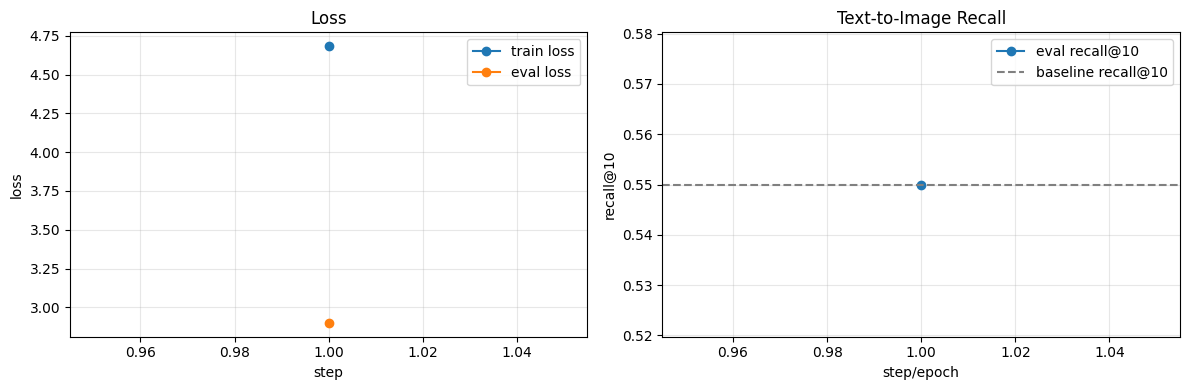

[{'loss': 4.683315753936768,
  'grad_norm': 19.156978607177734,
  'learning_rate': 0.0,
  'epoch': 0.5,
  'step': 1},
 {'eval_loss': 2.8997392654418945,
  'eval_model_preparation_time': 0.0048,
  'eval_vi_text_image_recall@1': 0.1,
  'eval_vi_text_image_recall@5': 0.36,
  'eval_vi_text_image_recall@10': 0.55,
  'eval_runtime': 0.6347,
  'eval_samples_per_second': 31.51,
  'eval_steps_per_second': 1.575,
  'epoch': 0.5,
  'step': 1},
 {'train_runtime': 6.1105,
  'train_samples_per_second': 20.948,
  'train_steps_per_second': 0.164,
  'total_flos': 0.0,
  'train_loss': 4.683315753936768,
  'epoch': 0.5,
  'step': 1}]

In [8]:
log_history = trainer.state.log_history

train_loss = [(row.get("step", i), row["loss"]) for i, row in enumerate(log_history) if "loss" in row]
eval_loss = [(row.get("step", i), row["eval_loss"]) for i, row in enumerate(log_history) if "eval_loss" in row]
eval_r10 = [
    (row.get("step", i), row["eval_vi_text_image_recall@10"])
    for i, row in enumerate(log_history)
    if "eval_vi_text_image_recall@10" in row
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if train_loss:
    axes[0].plot([x for x, _ in train_loss], [y for _, y in train_loss], marker="o", label="train loss")
if eval_loss:
    axes[0].plot([x for x, _ in eval_loss], [y for _, y in eval_loss], marker="o", label="eval loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if eval_r10:
    axes[1].plot([x for x, _ in eval_r10], [y for _, y in eval_r10], marker="o", label="eval recall@10")
else:
    axes[1].plot([row["epoch"] for row in evaluator.history], [row["recall@10"] for row in evaluator.history], marker="o", label="eval recall@10")
axes[1].axhline(baseline_score, linestyle="--", color="gray", label="baseline recall@10")
axes[1].set_title("Text-to-Image Recall")
axes[1].set_xlabel("step/epoch")
axes[1].set_ylabel("recall@10")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

log_history[-5:]

## 7. Inference Check

2026-05-17 00:14:42 - No device provided, using cuda:0
2026-05-17 00:14:42 - Loading SentenceTransformer model from D:\FactCheckPipeline\finetune\finetune\clip-vit-b32-finetuned\best.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

score images:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Query: Các cầu thủ bóng chày đang thi đấu ở trên sân .
Correct image_uid: 000000000001
Top results:
1. score=0.2298 image_uid=000000000020 
2. score=0.2084 image_uid=000000000007 
3. score=0.1950 image_uid=000000000019 
4. score=0.1889 image_uid=000000000003 
5. score=0.1872 image_uid=000000000002 


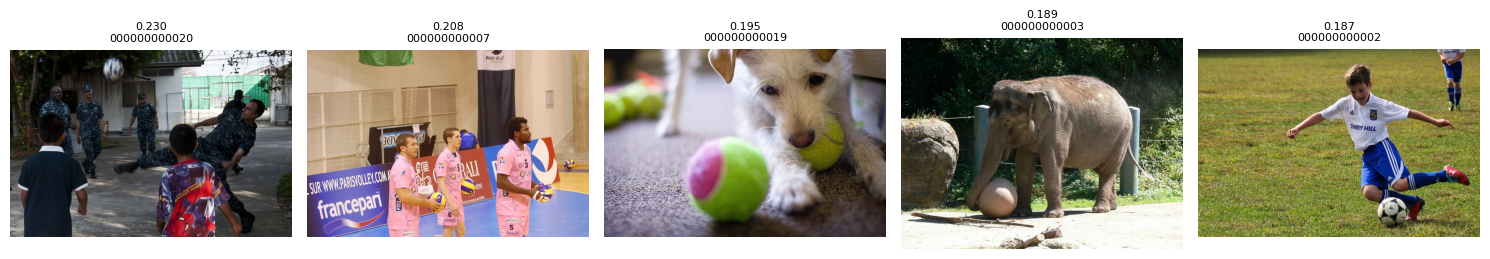

(torch.Size([1, 512]),
 'D:\\FactCheckPipeline\\finetune\\finetune\\clip-vit-b32-finetuned\\best')

In [9]:
best_model = SentenceTransformer(str(best_dir))
best_model.to(device)

sample = eval_full[0]
query = sample["text"]
correct_uid = sample["image_uid"]

image_by_uid = {}
for item in eval_full:
    if item["image_uid"] not in image_by_uid:
        image_by_uid[item["image_uid"]] = item["image"].convert("RGB")

image_uids = list(image_by_uid.keys())
images = [image_by_uid[uid] for uid in image_uids]

with autocast_ctx():
    query_vec = best_model.encode([query], normalize_embeddings=True, convert_to_tensor=True).cpu()

score_chunks = []
for start in tqdm(range(0, len(images), cfg["per_device_eval_batch_size"]), desc="score images"):
    batch_images = images[start:start + cfg["per_device_eval_batch_size"]]
    with autocast_ctx():
        image_vecs = best_model.encode(batch_images, batch_size=cfg["per_device_eval_batch_size"], normalize_embeddings=True, convert_to_tensor=True).cpu()
    score_chunks.append((query_vec @ image_vecs.T).squeeze(0))
    del image_vecs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

scores = torch.cat(score_chunks, dim=0)
top_k = min(5, len(image_uids))
top = scores.topk(top_k)

print("Query:", query)
print("Correct image_uid:", correct_uid)
print("Top results:")
for rank, (idx, score) in enumerate(zip(top.indices.tolist(), top.values.tolist()), start=1):
    uid = image_uids[idx]
    mark = "<-- correct" if uid == correct_uid else ""
    print(f"{rank}. score={score:.4f} image_uid={uid} {mark}")

fig, axes = plt.subplots(1, top_k, figsize=(3 * top_k, 3))
if top_k == 1:
    axes = [axes]
for ax, idx, score in zip(axes, top.indices.tolist(), top.values.tolist()):
    uid = image_uids[idx]
    ax.imshow(image_by_uid[uid])
    title = f"{score:.3f}\n{uid}"
    if uid == correct_uid:
        title = "CORRECT\n" + title
    ax.set_title(title, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

query_vec.shape, str(best_dir)